In [16]:
import os
import numpy as np
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


In [17]:
def build_importance_from_pgdiff(pg_root, out_path, target_layers, n_classes=4, pca_components=4):
    """
    For each layer l:
      - load pg_correct - pg_incorrect for each class
      - PCA across classes
      - importance per neuron = abs(mean projection scores across top components)
    Saves: npz with importance per layer
    """
    importance = {}
    print("pg_root", pg_root)
    print("out_path", out_path)
    for l in target_layers:
        diffs = []
        for cls in range(n_classes):
            p_c = os.path.join(pg_root, "correct", "pg1_data", f"{cls}_layer{l}_ffn_pg1.npy")
            p_i = os.path.join(pg_root, "incorrect", "pg1_data", f"{cls}_layer{l}_ffn_pg1.npy")
            if not (os.path.exists(p_c) and os.path.exists(p_i)):
                continue
            diffs.append(np.load(p_c) - np.load(p_i))

        diffs = np.array(diffs)
        if diffs.size == 0:
            print(f"Skipping layer {l}: no PG diff data.")
            continue

        k = min(pca_components, diffs.shape[0], diffs.shape[1])
        pca = PCA(n_components=k)
        pca.fit(diffs)
        comps = pca.components_  # (k, units)

        # neuron importance: mean abs across components
        imp = np.mean(np.abs(comps), axis=0)
        imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-12)
        importance[f"layer{l}"] = imp.astype(np.float32)

        print(f"✔ importance built for layer {l} (units={imp.shape[0]})")

    np.savez(out_path, **importance)
    print(f"Saved importance to: {out_path}")

In [18]:
build_importance_from_pgdiff(
    "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/pg",
    "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/importance_ffn.npz",
    target_layers=[0, 5, 11],
    n_classes=1,
    pca_components=4
)

pg_root /home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/pg
out_path /home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/importance_ffn.npz
✔ importance built for layer 0 (units=3072)
✔ importance built for layer 5 (units=3072)
✔ importance built for layer 11 (units=3072)
Saved importance to: /home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/importance_ffn.npz


/home/charuka09/Documents/postPhD/mindula/icml/venv/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
/home/charuka09/Documents/postPhD/mindula/icml/venv/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
/home/charuka09/Documents/postPhD/mindula/icml/venv/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


In [20]:
imp = np.load("/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/new/importance_ffn.npz")
for k in imp:
    print(
        k,
        "min", imp[k].min(),
        "max", imp[k].max(),
        "mean", imp[k].mean()
    )

layer0 min 0.0 max 1.0 mean 0.0237619
layer5 min 0.0 max 1.0 mean 0.020127257
layer11 min 0.0 max 1.0 mean 0.03582887


In [21]:
def plot_pg1_contrast(pg_root, cls, layer, title, save_path=None, top_k=3072):
    p_c = f"{pg_root}/correct/pg1_data/{cls}_layer{layer}_ffn_pg1.npy"
    p_i = f"{pg_root}/incorrect/pg1_data/{cls}_layer{layer}_ffn_pg1.npy"

    c = np.load(p_c)
    i = np.load(p_i)

    # normalize each
    c = (c - c.min()) / (c.max() - c.min() + 1e-12)
    i = (i - i.min()) / (i.max() - i.min() + 1e-12)
    contrast = c - i

    # top-k by contrast magnitude
    idx = np.argsort(np.abs(contrast))[::-1][:top_k]
    idx = np.sort(idx)

    x = np.arange(len(idx))

    plt.figure(figsize=(10, 4))
    plt.plot(x, c[idx], "o-", label="Correct PG1")
    plt.plot(x, i[idx], "o-", label="Incorrect PG1")
    plt.plot(x, contrast[idx], "--", label="Contrast PG1 (C - I)")
    plt.title(title)
    plt.xlabel(f"Top-{top_k} neurons (sorted)")
    plt.ylabel("Normalized PG1 value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

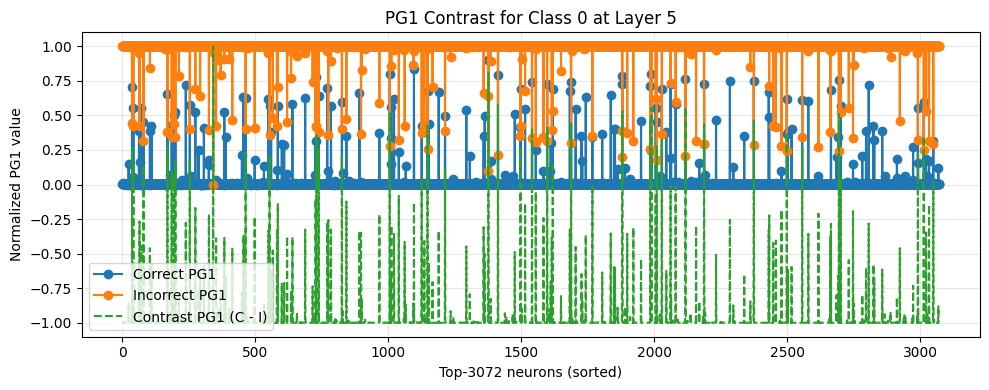

In [22]:
pg_root = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/new/pg"

plot_pg1_contrast(
    pg_root,
    cls=0,
    layer=5,
    title="PG1 Contrast for Class 0 at Layer 5"
)

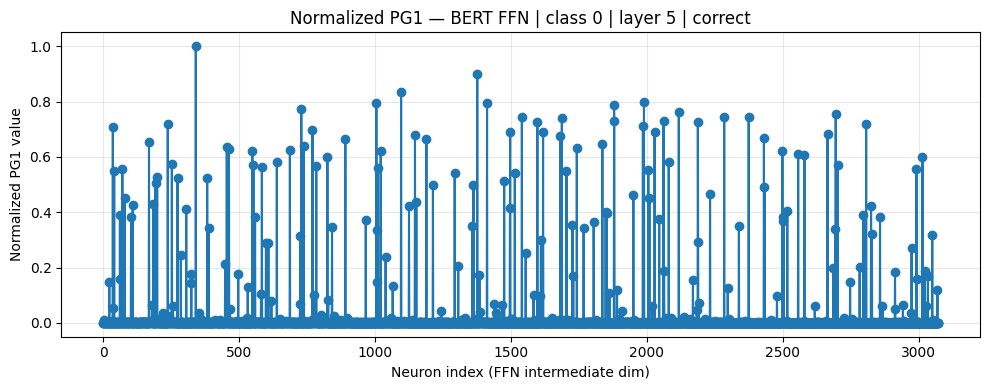

In [23]:
cls=0
layer=5
p_c = f"{pg_root}/correct/pg1_data/{cls}_layer{layer}_ffn_pg1.npy"
pg1 = np.load(p_c)  # <-- this is the vector (shape: [3072])

# Normalize to [0, 1]
pg1_norm = (pg1 - pg1.min()) / (pg1.max() - pg1.min() + 1e-12)

plt.figure(figsize=(10, 4))
plt.plot(pg1_norm, marker="o", linestyle="-")
plt.title(f"Normalized PG1 — BERT FFN | class {cls} | layer {layer} | correct")
plt.xlabel("Neuron index (FFN intermediate dim)")
plt.ylabel("Normalized PG1 value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

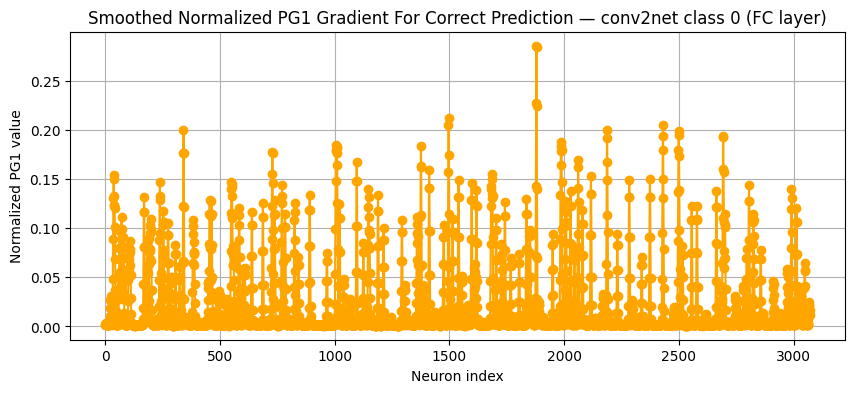

In [24]:
pg1_smooth = gaussian_filter1d(pg1_norm, sigma=2)

plt.figure(figsize=(10,4))
plt.plot(pg1_smooth, marker='o', linestyle='-', color='orange')
plt.title("Smoothed Normalized PG1 Gradient For Correct Prediction — conv2net class 0 (FC layer)")
plt.xlabel("Neuron index")
plt.ylabel("Normalized PG1 value")
plt.grid(True)
plt.show()

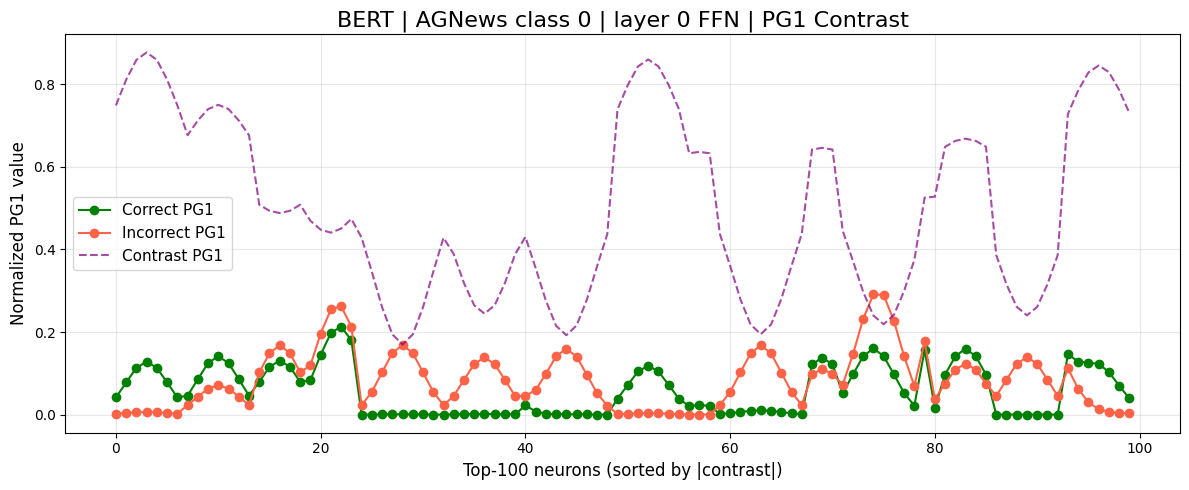

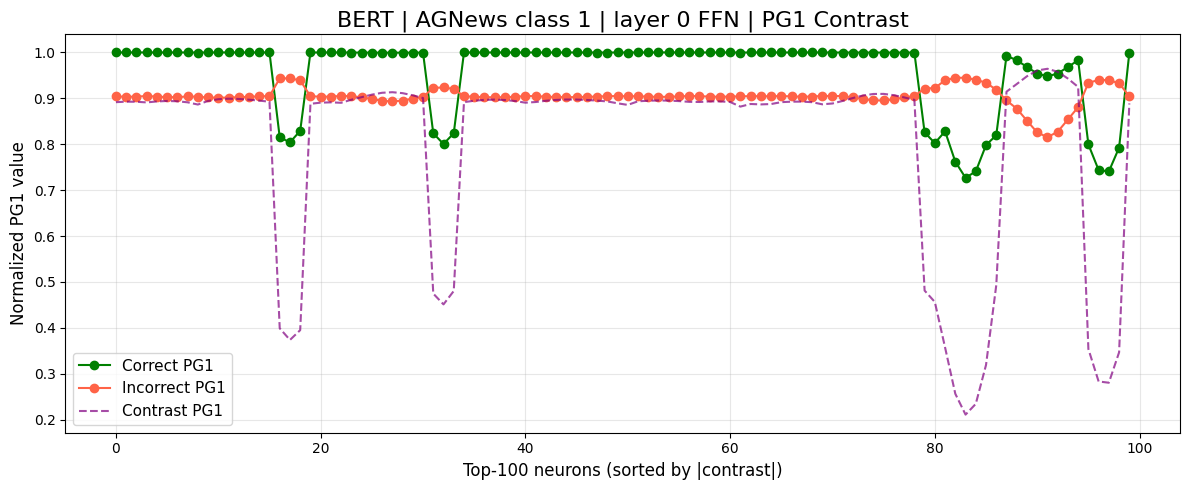

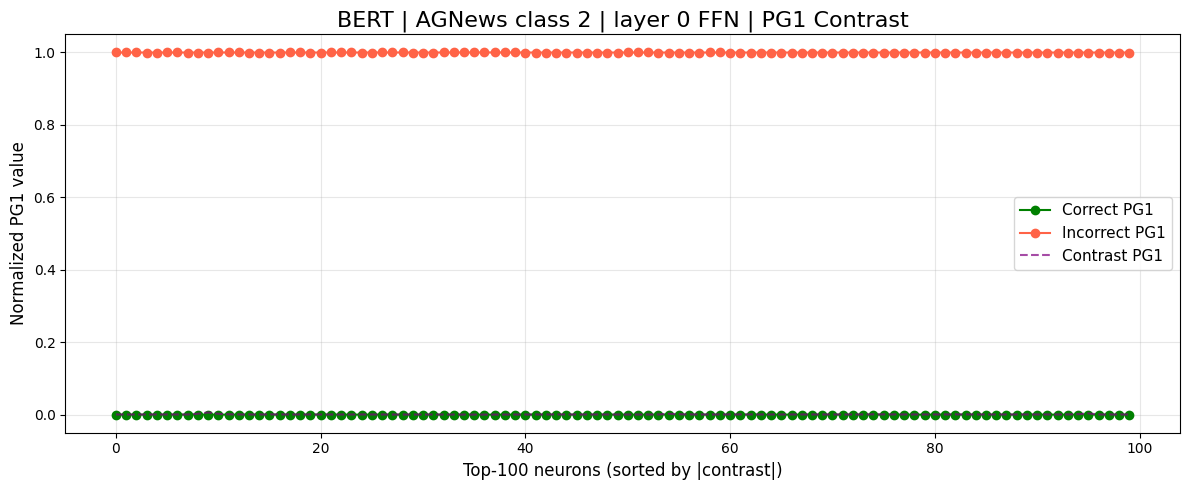

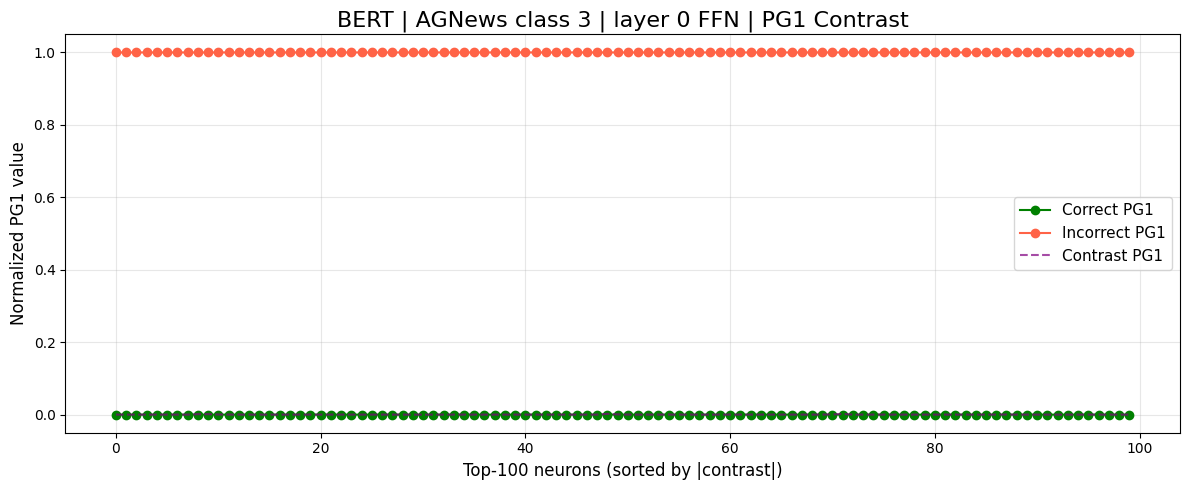

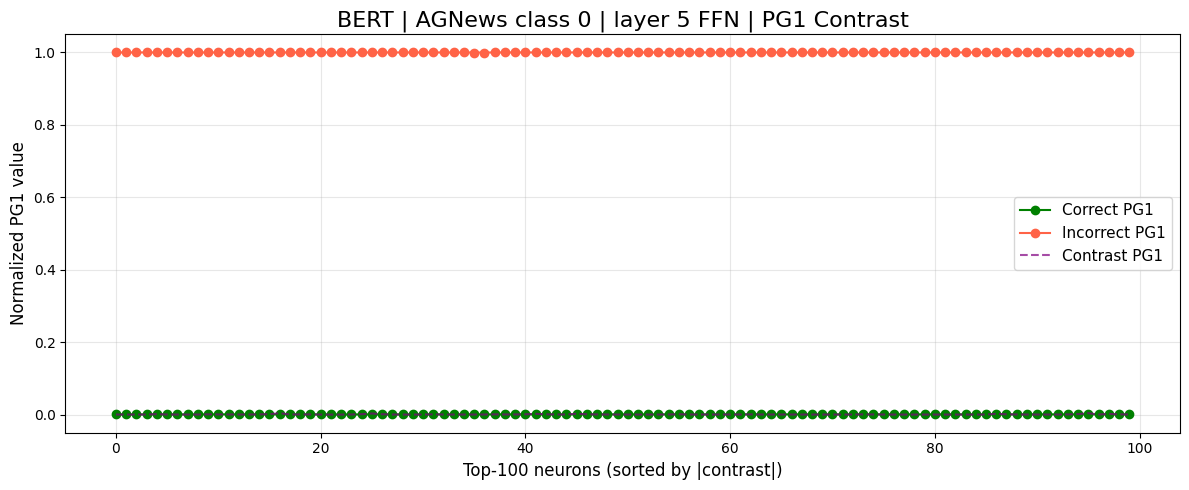

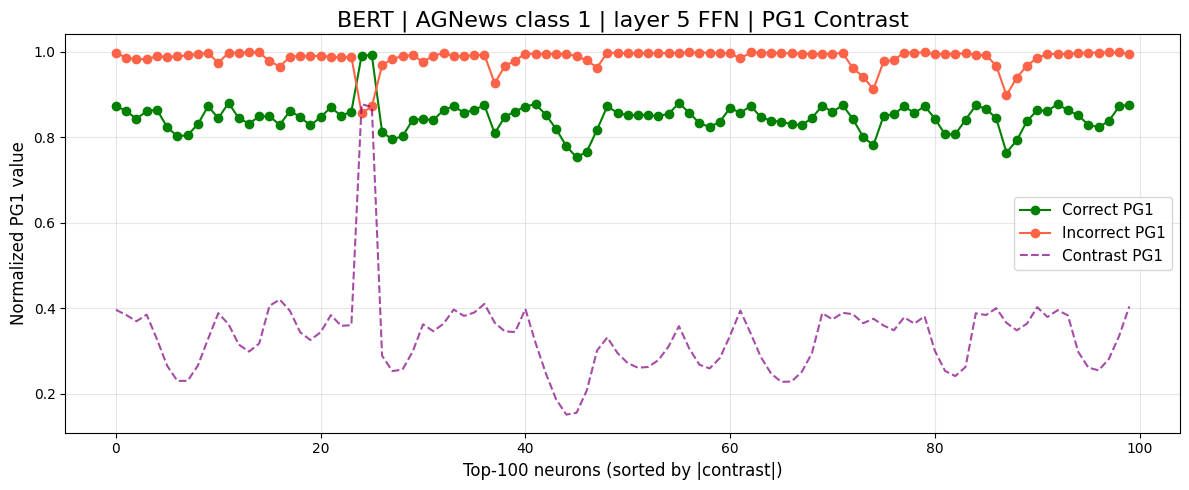

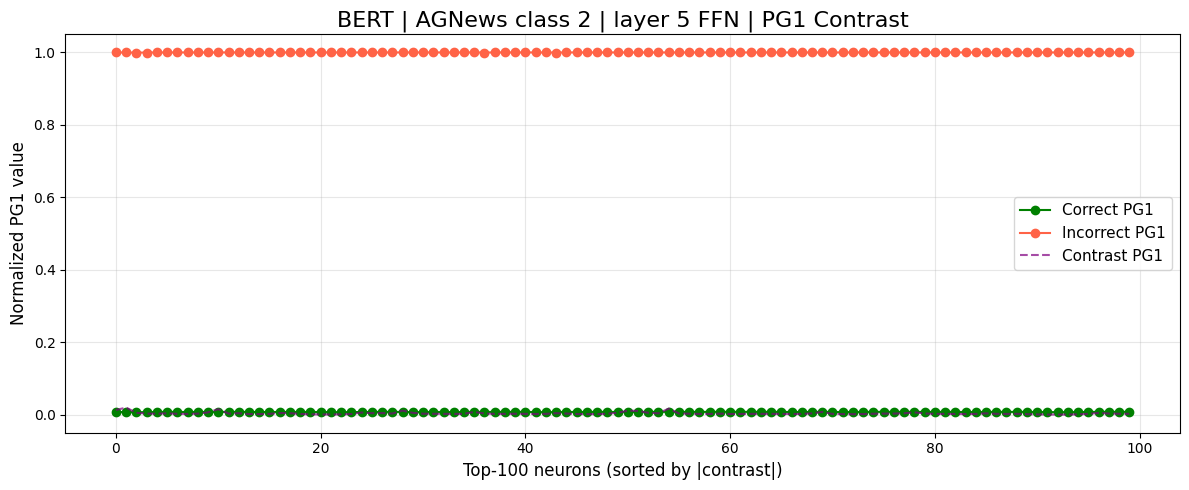

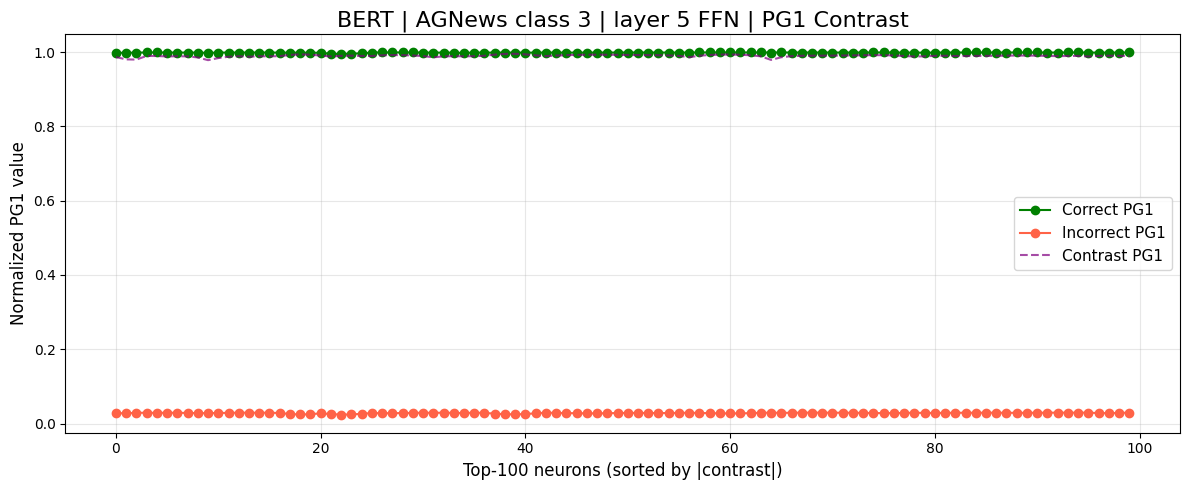

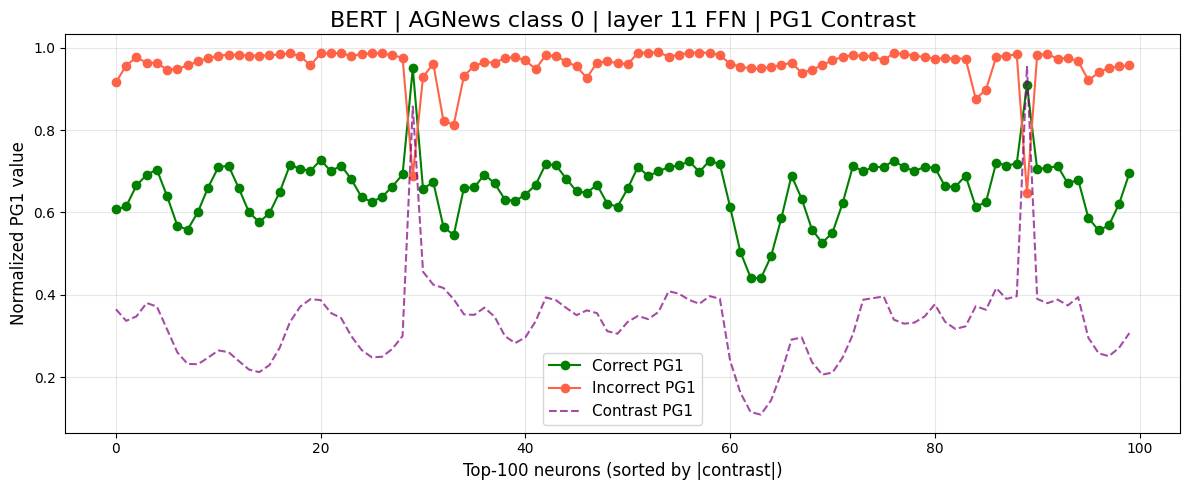

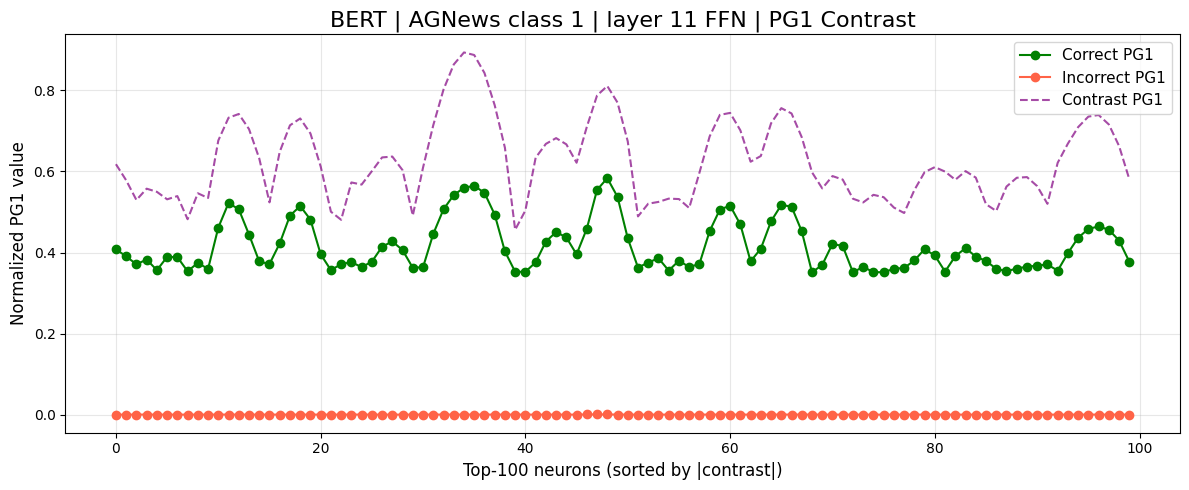

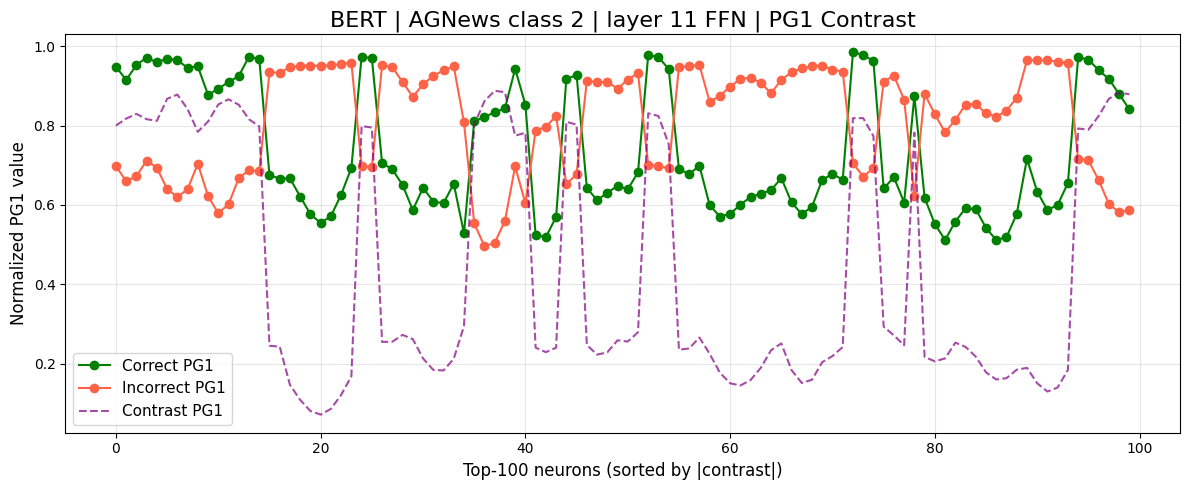

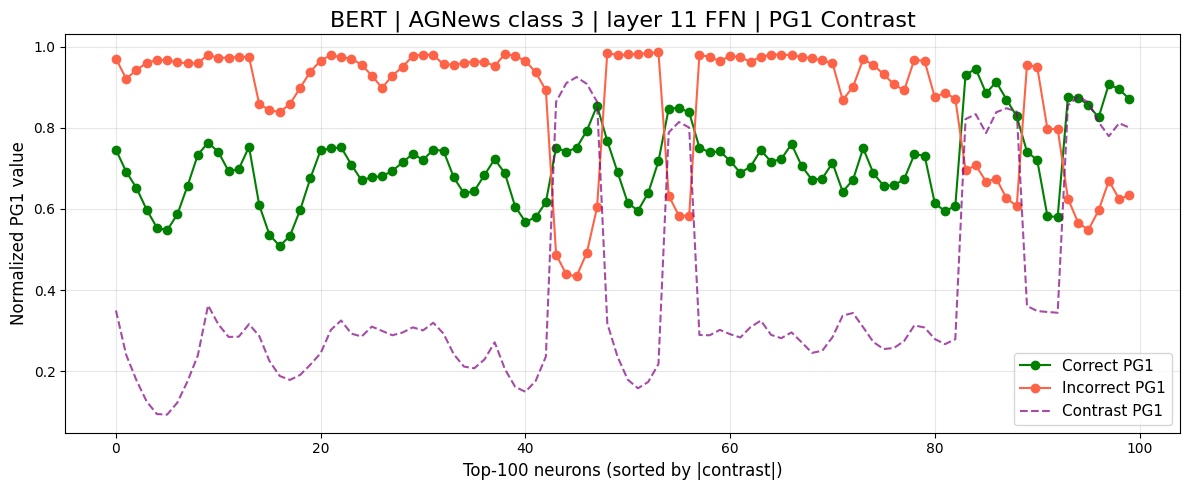

In [35]:
# ----------------------------
# Config (EDIT THESE)
# ----------------------------
pg1_base_root = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/new/"  # <-- your root
layers = [0, 5, 11]
classes = [0, 1, 2, 3]  # AG News
sigma_smooth = 2

# Plot style
color_correct = "green"
color_incorrect = "tomato"
color_contrast = "purple"
marker = "o"

# Choose ONE plotting style:
PLOT_STYLE = "topk"      # "topk" or "downsample" or "full"
TOP_K = 100               # used if style="topk"
DOWNSAMPLE_EVERY = 10     # used if style="downsample"


# ----------------------------
# Helpers
# ----------------------------
def load_pg1_vector(file_path):
    """Load PG1 vector (no normalization here)."""
    if not os.path.exists(file_path):
        print(f"⚠ File not found: {file_path}")
        return None
    pg = np.load(file_path)
    if pg.size == 0:
        print(f"⚠ Empty PG1: {file_path}")
        return None
    return pg

def normalize_01(x):
    x = np.asarray(x)
    if np.allclose(x.max(), x.min()):
        return None  # constant vector → bad / not informative
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

def plot_pg1_contrast(pg_correct, pg_incorrect, title, save_path=None):
    """
    Plot correct, incorrect, and contrast vectors (Conv2Net-like),
    but adapted for long BERT vectors (3072 dims).
    """
    c = normalize_01(pg_correct)
    i = normalize_01(pg_incorrect)
    if c is None or i is None:
        print("⚠ Skipping: PG1 vector constant (cannot normalize).")
        return

    # smooth correct/incorrect (optional)
    c_s = gaussian_filter1d(c, sigma=sigma_smooth)
    i_s = gaussian_filter1d(i, sigma=sigma_smooth)

    # contrast
    contrast = c_s - i_s
    contrast_n = normalize_01(contrast)
    if contrast_n is None:
        print("⚠ Skipping: contrast constant (unlikely but possible).")
        return
    contrast_s = gaussian_filter1d(contrast_n, sigma=sigma_smooth)

    # ----- choose what to plot on x-axis -----
    if PLOT_STYLE == "topk":
        # Plot the TOP-K most different neurons (cleanest)
        idx = np.argsort(np.abs(contrast))[::-1][:TOP_K]
        idx = np.sort(idx)  # nicer left-to-right order
        x = np.arange(len(idx))

        y_c = c_s[idx]
        y_i = i_s[idx]
        y_con = contrast_s[idx]
        x_label = f"Top-{TOP_K} neurons (sorted by |contrast|)"

    elif PLOT_STYLE == "downsample":
        idx = np.arange(0, len(c_s), DOWNSAMPLE_EVERY)
        x = idx
        y_c = c_s[idx]
        y_i = i_s[idx]
        y_con = contrast_s[idx]
        x_label = f"Neuron index (every {DOWNSAMPLE_EVERY}th)"

    else:  # "full"
        x = np.arange(len(c_s))
        y_c = c_s
        y_i = i_s
        y_con = contrast_s
        x_label = "Neuron index (all 3072)"

    # ----- plot -----
    plt.figure(figsize=(12, 5))
    plt.plot(x, y_c, marker=marker, linestyle="-", color=color_correct, label="Correct PG1")
    plt.plot(x, y_i, marker=marker, linestyle="-", color=color_incorrect, label="Incorrect PG1")
    plt.plot(x, y_con, linestyle="--", color=color_contrast, alpha=0.7, label="Contrast PG1")

    plt.title(title, fontsize=16)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Normalized PG1 value", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()


# ----------------------------
# Main loop
# ----------------------------
def visualize_pg1_bert(pg1_base_root, layers, classes):
    """
    Expected structure:
      {pg1_base_root}/pg/correct/pg1_data/{cls}_layer{layer}_ffn_pg1.npy
      {pg1_base_root}/pg/incorrect/pg1_data/{cls}_layer{layer}_ffn_pg1.npy
    """
    for layer in layers:
        for cls in classes:
            path_correct = os.path.join(
                pg1_base_root, "pg", "correct", "pg1_data",
                f"{cls}_layer{layer}_ffn_pg1.npy"
            )
            path_incorrect = os.path.join(
                pg1_base_root, "pg", "incorrect", "pg1_data",
                f"{cls}_layer{layer}_ffn_pg1.npy"
            )

            pg_c = load_pg1_vector(path_correct)
            pg_i = load_pg1_vector(path_incorrect)
            if pg_c is None or pg_i is None:
                continue

            title = f"BERT | AGNews class {cls} | layer {layer} FFN | PG1 Contrast"
            # optional: save figures
            save_path = os.path.join(
                pg1_base_root, "pg", "plots_pg1_contrast",
                f"class{cls}_layer{layer}_{PLOT_STYLE}.png"
            )

            plot_pg1_contrast(pg_c, pg_i, title=title, save_path=save_path)


# ----------------------------
# Run
# ----------------------------
visualize_pg1_bert(pg1_base_root, layers, classes)

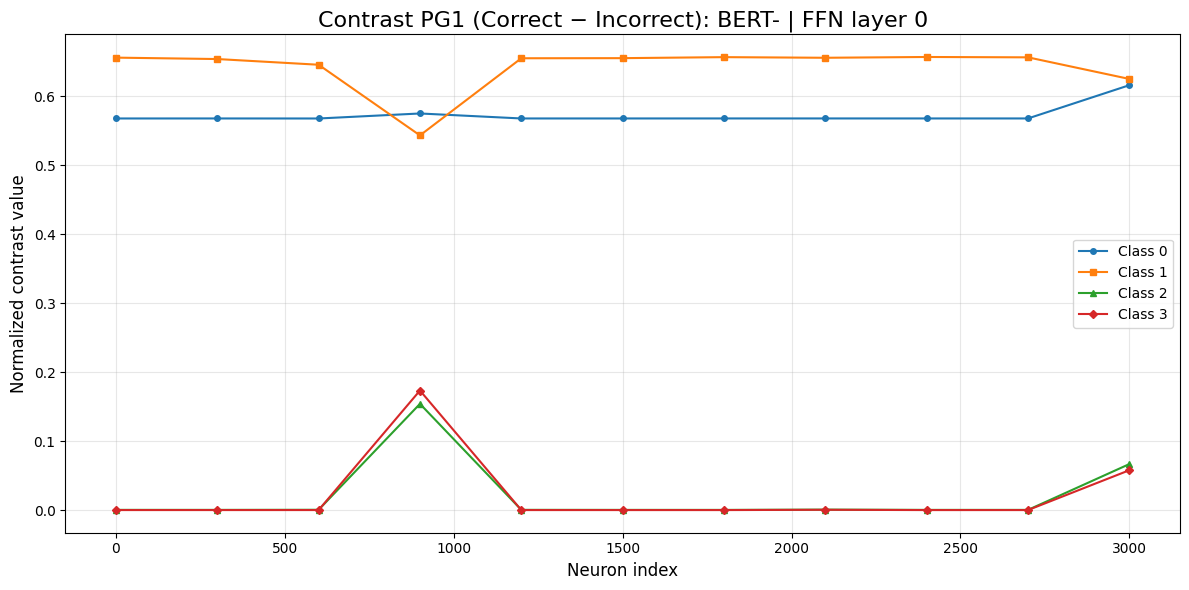

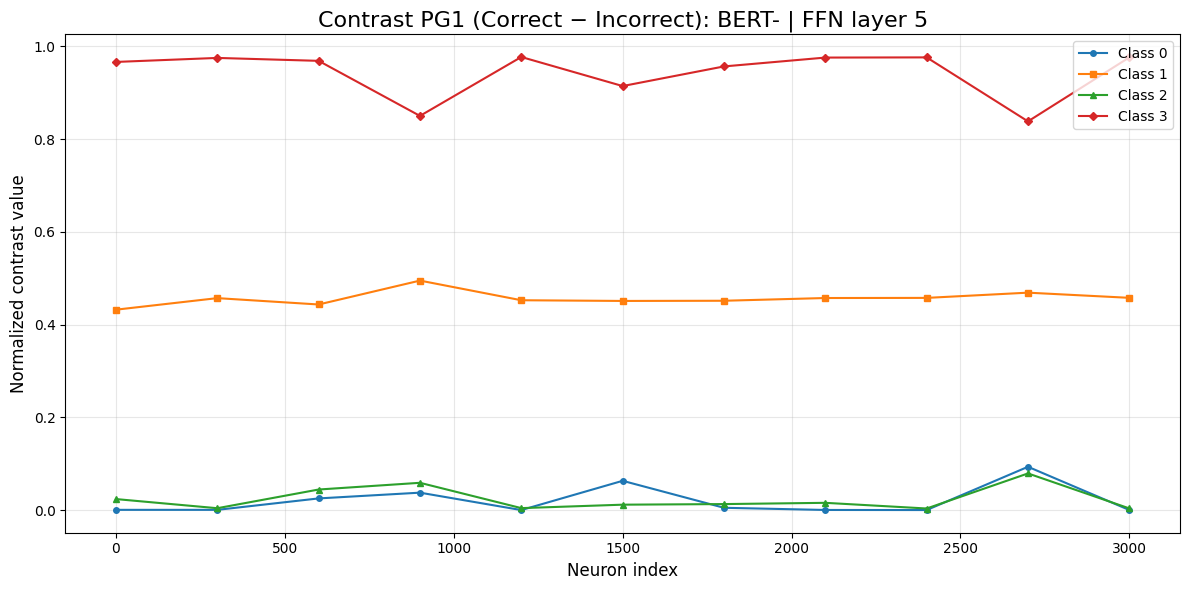

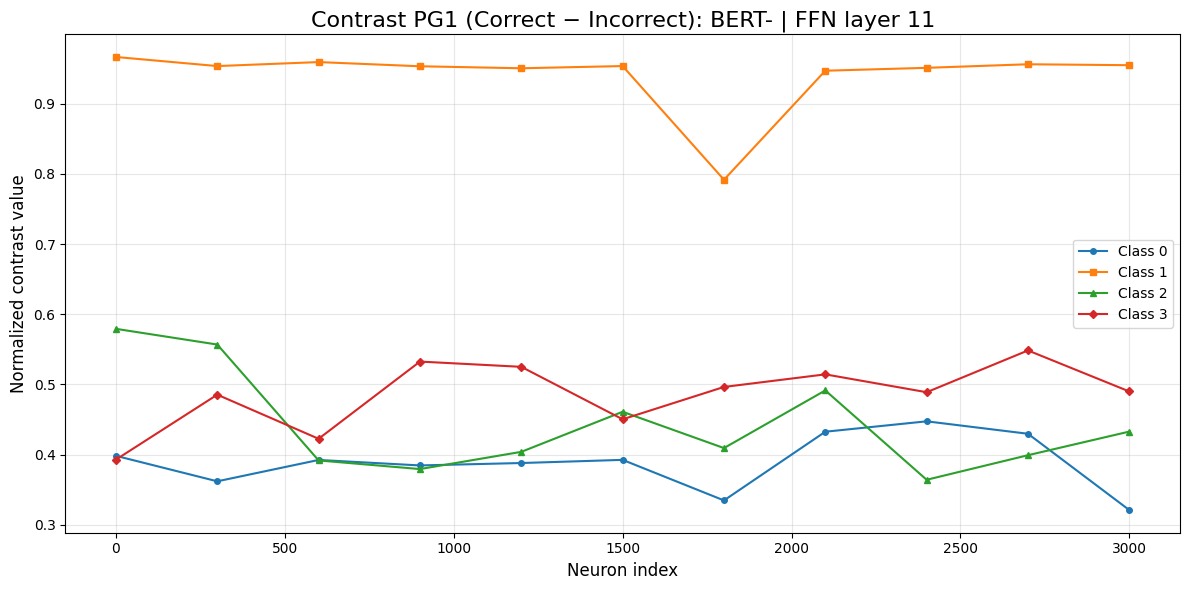

In [33]:

# Settings (EDIT THESE)
# ----------------------------
pg_root = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/new/" # parent that contains head/ and full/

target_layers = [0, 5, 11]
num_classes = 4                 # AG News
sigma_smooth = 2
DOWNSAMPLE_EVERY = 300            # for BERT 3072 dims; set 1 to plot all points (not recommended)

colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']


# ----------------------------
# Safe loader
# ----------------------------
def load_pg1(path):
    if not os.path.exists(path):
        print(f"⚠ File not found: {path}")
        return None
    pg = np.load(path)
    if pg.size == 0 or np.all(pg == pg[0]):
        print(f"⚠ PG1 vector empty or constant: {path}")
        return None
    return pg


def normalize_01(x):
    x = np.asarray(x)
    denom = (x.max() - x.min()) + 1e-12
    if denom < 1e-12:
        return None
    return (x - x.min()) / denom


# ----------------------------
# Plot per layer
# ----------------------------
for layer in target_layers:
    plt.figure(figsize=(12, 6))
    any_plotted = False

    for cls in range(num_classes):
        path_corr = os.path.join(
            pg_root, "pg", "correct", "pg1_data",
            f"{cls}_layer{layer}_ffn_pg1.npy"
        )
        path_inc = os.path.join(
            pg_root, "pg", "incorrect", "pg1_data",
            f"{cls}_layer{layer}_ffn_pg1.npy"
        )

        pg_corr = load_pg1(path_corr)
        pg_inc = load_pg1(path_inc)
        if pg_corr is None or pg_inc is None:
            continue

        contrast = pg_corr - pg_inc
        contrast_norm = normalize_01(contrast)
        if contrast_norm is None:
            continue

        contrast_smooth = gaussian_filter1d(contrast_norm, sigma=sigma_smooth)

        # Downsample for readability (3072 dims is too dense)
        idx = np.arange(0, contrast_smooth.shape[0], DOWNSAMPLE_EVERY)
        y = contrast_smooth[idx]

        plt.plot(
            idx, y,
            marker=markers[cls % len(markers)],
            linestyle='-',
            linewidth=1.5,
            markersize=4,
            color=colors[cls % len(colors)],
            label=f"Class {cls}"
        )
        any_plotted = True

    plt.title(f"Contrast PG1 (Correct − Incorrect): BERT- | FFN layer {layer}", fontsize=16)
    plt.xlabel("Neuron index", fontsize=12)
    plt.ylabel("Normalized contrast value", fontsize=12)
    plt.grid(True, alpha=0.3)
    if any_plotted:
        plt.legend()
    plt.tight_layout()
    plt.show()